In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import os
import csv
import pandas as pd

import scipy.stats
from sklearn.linear_model import LinearRegression

import torch
from networks_update import Encoder, Decoder
import math
import random

In [2]:
# helper functions
def plot_img(img_arr, slice_idx, title="", cmap="gray"):
    plt.figure(figsize=(2,2))
    plt.imshow(img_arr[slice_idx, :, :], cmap)
    plt.title(title)
    plt.colorbar()
    plt.show()

## Notebook for maping between latents and prelim evaluation of the translation

#### Translating

In [3]:
# folder to save model checkpoints
encoder_save_folder = "./save_models/mouse_train_5/"
decoder_save_folder = "./save_models/human_train_5/"

# checkpoint to load
encoder_epoch = 500
decoder_epoch = 500

# Encode with mouse encoder and decode with human decoder
test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/test/images/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]
test_paths.sort()
idx = 2

img = sitk.ReadImage(test_paths[idx])
img_arr = sitk.GetArrayFromImage(img)
img_arr = np.expand_dims(img_arr, axis=0)
img_torch = torch.from_numpy(img_arr).to(torch.float)

# Initialize model
encoder = Encoder(n_downsample=2, n_res=4, input_dim=1, dim=4, norm='in', activ='relu', pad_type='zero')
decoder_recon = Decoder(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=4)
decoder_trans = Decoder(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=4)

# load models checkpoint to test
encoder.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['encoder_state_dict'])
decoder_recon.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['decoder_state_dict'])
decoder_trans.load_state_dict(torch.load(decoder_save_folder + "checkpoint_epoch_" + str(decoder_epoch))['decoder_state_dict'])

z = encoder(img_torch.unsqueeze(0))

recon_img = decoder_recon(z)
recon_img = torch.argmax(recon_img, dim=1)
recon_img = np.array(recon_img.squeeze())

trans_img = decoder_trans(z)
trans_img = torch.argmax(trans_img, dim=1)
trans_img = np.array(trans_img.squeeze())

In [ ]:
# Test 1 - what does the model produce when passed the encoding of the other species (mouse -> human)
# Q1 - does the produced img look reasonable??

slice_idx = 60
plot_img(img_arr.squeeze(), slice_idx, "Img")
plot_img(recon_img, slice_idx, "Recon")
plot_img(trans_img, slice_idx, "Trans")

In [ ]:
# Translate all images in folder to their latent encodings

folder_to_encode = test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/images/"
save_path = "./save_models/mouse_train_5/train_latent_encodings/"
encoder_save_folder = "./save_models/mouse_train_5/"
encoder_epoch = 500

# folder_to_encode = test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/labels/"
# save_path = "./save_models/human_train_5/train_latent_encodings/"
# encoder_save_folder = "./save_models/human_train_5/"
# encoder_epoch = 500

#os.mkdir(save_path)

# Initialize model
encoder = Encoder(n_downsample=2, n_res=4, input_dim=1, dim=4, norm='in', activ='relu', pad_type='zero')

# load models checkpoint to test
encoder.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['encoder_state_dict'])

for file_name in os.listdir(folder_to_encode):
    img = sitk.ReadImage(folder_to_encode + file_name)
    img_arr = sitk.GetArrayFromImage(img)
    img_arr = np.expand_dims(img_arr, axis=0)
    img_torch = torch.from_numpy(img_arr).to(torch.float)

    z = encoder(img_torch.unsqueeze(0))

    torch.save(z, save_path + "encoded_" + file_name + ".pt")



#### Mapping

In [3]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

class ElementWiseLinear(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))  # scaling factors
        #self.bias = nn.Parameter(torch.zeros(dim))   # biases

    def forward(self, x):
        return x * self.weight # + self.bias


latent_shape = [16, 32, 30, 30]
latent_len = math.prod(latent_shape)
middle_feat = 1024

MLP = nn.Sequential(
    nn.Linear(latent_len, middle_feat),  # compress
    nn.ReLU(),
    nn.LayerNorm(middle_feat),

    nn.Linear(middle_feat, middle_feat),    # map in latent space
    nn.ReLU(),
    nn.LayerNorm(middle_feat),

    nn.Linear(middle_feat, latent_len)   # reconstruct
)

class LatentVectorDataset(Dataset):
    def __init__(self, mouse_encodings_folder, human_encodings_folder):
        self.mouse_encodings_folder = mouse_encodings_folder
        self.human_encodings_folder = human_encodings_folder

        self.mouse_encodings_files = os.listdir(mouse_encodings_folder)
        random.shuffle(self.mouse_encodings_files)
        self.human_encodings_files = os.listdir(human_encodings_folder)
    
    def __len__(self):
        return len(self.mouse_encodings_files)
    
    def __getitem__(self, idx):
        mouse_encoding = torch.load(self.mouse_encodings_folder + self.mouse_encodings_files[idx]).flatten().detach()
        human_encoding = torch.load(self.human_encodings_folder + self.human_encodings_files[idx]).flatten().detach()
        return mouse_encoding, human_encoding
    
    
class LatentVectorAllToAllDataset(Dataset):
    def __init__(self, mouse_encodings_folder, human_encodings_folder):
        self.mouse_encodings_folder = mouse_encodings_folder
        self.human_encodings_folder = human_encodings_folder

        self.mouse_encodings_files = os.listdir(mouse_encodings_folder)
        self.human_encodings_files = os.listdir(human_encodings_folder)

        num_samples = len(self.mouse_encodings_files)
        self.mouse_idxs = np.ones(num_samples**2, dtype=int)

        # To pair every idx with every idx...
        for i in range(num_samples):
            # set mouse_idxs to be [0, 0, ..., 1, 1, ..., ......, num_samples-1, num_samples-1, ...]
            self.mouse_idxs[i*num_samples : (i+1)*num_samples] = i

        # set human_idxs to be [0, 1, ..., num_samples-1, ........, 0, 1, ..., num_samples-1]
        self.human_idxs = np.arange(num_samples**2) % num_samples

        # Shuffle the pairs to get the train dataset

        perm = np.random.permutation(num_samples**2)
        self.human_idxs = self.human_idxs[perm]
        self.mouse_idxs = self.mouse_idxs[perm]
    
    def __len__(self):
        return len(self.mouse_idxs)
    
    def __getitem__(self, idx):
        mouse_encoding = torch.load(self.mouse_encodings_folder + self.mouse_encodings_files[self.mouse_idxs[idx]]).flatten().detach()
        human_encoding = torch.load(self.human_encodings_folder + self.human_encodings_files[self.human_idxs[idx]]).flatten().detach()
        return mouse_encoding, human_encoding

In [44]:
# Test out different models to learn the mapping between latent vectors

# load data into random ordered vectors
mouse_encodings_folder = "./save_models/mouse_train_5/train_latent_encodings/"
human_encodings_folder = "./save_models/human_train_5/train_latent_encodings/"

dataset = LatentVectorDataset(mouse_encodings_folder, human_encodings_folder)
batch_size = 4
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

model = MLP.cuda() #ElementWiseLinear(latent_len).cuda()  # move to GPU
#model.load_state_dict(torch.load('./save_mapping_models/train_5/test_6_MLP_layer_norm.pth'))

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
start_epoch = 0
epochs = 200
save_loss = []
epsilon = 1e-6
print("start training!!")
for epoch in range(start_epoch, epochs + start_epoch):
    running_loss = 0.0
    for mouse_batch, human_batch in dataloader:
        # normalize batches
        #mouse_batch = (mouse_batch - mouse_means) / (mouse_stds + epsilon) 
        #human_batch = (human_batch - human_means) / (human_stds + epsilon) 

        mouse_batch = mouse_batch.cuda()
        human_batch = human_batch.cuda()

        optimizer.zero_grad()
        outputs = model(mouse_batch)
        loss = criterion(outputs, human_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * mouse_batch.size(0)

    epoch_loss = running_loss / len(dataset)
    save_loss.append(epoch_loss)
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss:.6f}")

# will take ~20 min :(


start training!!
Epoch 1, Loss: 0.401927
Epoch 2, Loss: 0.390603
Epoch 3, Loss: 0.383614
Epoch 4, Loss: 0.386393
Epoch 5, Loss: 0.378953
Epoch 6, Loss: 0.380931
Epoch 7, Loss: 0.372878
Epoch 8, Loss: 0.372912
Epoch 9, Loss: 0.360545
Epoch 10, Loss: 0.358629
Epoch 11, Loss: 0.356755
Epoch 12, Loss: 0.348568
Epoch 13, Loss: 0.336063
Epoch 14, Loss: 0.327918
Epoch 15, Loss: 0.323716
Epoch 16, Loss: 0.319127
Epoch 17, Loss: 0.302933
Epoch 18, Loss: 0.292864
Epoch 19, Loss: 0.289224
Epoch 20, Loss: 0.278325
Epoch 21, Loss: 0.256943
Epoch 22, Loss: 0.252211
Epoch 23, Loss: 0.243370
Epoch 24, Loss: 0.244172
Epoch 25, Loss: 0.239070
Epoch 26, Loss: 0.233014
Epoch 27, Loss: 0.214742
Epoch 28, Loss: 0.195670
Epoch 29, Loss: 0.201870
Epoch 30, Loss: 0.189258
Epoch 31, Loss: 0.177593
Epoch 32, Loss: 0.169382
Epoch 33, Loss: 0.164038
Epoch 34, Loss: 0.157553
Epoch 35, Loss: 0.150501
Epoch 36, Loss: 0.151140
Epoch 37, Loss: 0.140174
Epoch 38, Loss: 0.134990
Epoch 39, Loss: 0.133710
Epoch 40, Loss: 0

In [45]:
# save the mapping model

#torch.save(model.state_dict(), 'test_1_element_wise.pth')
#torch.save(model.state_dict(), 'test_2_element_wise_1_to_1.pth')
#torch.save(model.state_dict(), './save_mapping_models/train_5/test_3_MLP_middle_1024_epoch_201.pth')
#torch.save(model.state_dict(), './save_mapping_models/train_5/test_3_MLP_middle_1024_all_to_all_8_epoch.pth')

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch
}, './save_mapping_models/train_5/test_6_MLP_layer_norm.pth')

# save the loss too
np.save("./save_mapping_models/train_5/test_6_MLP_layer_norm_loss", save_loss)

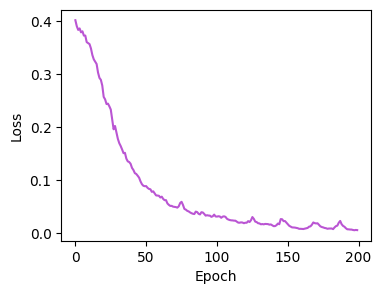

In [46]:
# plot loss

plt.figure(figsize=(4,3))
plt.plot(np.arange(start_epoch, epochs + start_epoch), save_loss, color="mediumorchid")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [4]:
# Now test the translating model!!!
# (for a sample decode to reconstructed and transaated - with model trained above)

# folder with model checkpoints
encoder_save_folder = "./save_models/mouse_train_5/"
decoder_save_folder = "./save_models/human_train_5/"

# checkpoint to load
encoder_epoch = 500
decoder_epoch = 500

# Encode with mouse encoder and decode with human decoder
test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/images/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)][:56]
test_paths.sort()

idxs = np.arange(len(test_paths))

# folder to save translated images to
save_path = "./save_translations/train_5_map_6_train_set/"
os.makedirs(save_path)

# Initialize model
encoder = Encoder(n_downsample=2, n_res=4, input_dim=1, dim=4, norm='in', activ='relu', pad_type='zero')
decoder_recon = Decoder(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=4)
decoder_trans = Decoder(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=4)

# load models checkpoint to test
encoder.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['encoder_state_dict'])
decoder_recon.load_state_dict(torch.load(encoder_save_folder + "checkpoint_epoch_" + str(encoder_epoch))['decoder_state_dict'])
decoder_trans.load_state_dict(torch.load(decoder_save_folder + "checkpoint_epoch_" + str(decoder_epoch))['decoder_state_dict'])

# load the mapping model too OR reuse from above
model = MLP.cuda() 
model.load_state_dict(torch.load('./save_mapping_models/train_5/test_6_MLP_layer_norm.pth')['model_state_dict'])

encoder.eval()
decoder_recon.eval()
decoder_trans.eval()
model.eval()

for idx in idxs:
    img = sitk.ReadImage(test_paths[idx])
    img_arr = sitk.GetArrayFromImage(img)
    img_arr = np.expand_dims(img_arr, axis=0)
    img_torch = torch.from_numpy(img_arr).to(torch.float)

    z = encoder(img_torch.unsqueeze(0))

    # the translating model trained above
    z_trans = model(z.flatten().cuda()).cpu()#*human_stds + human_means

    # de-normalize before reshaping
    z_trans = z_trans.reshape(z.shape)

    #recon_img = decoder_recon(z)
    #recon_img = torch.argmax(recon_img, dim=1)
    #recon_img = np.array(recon_img.squeeze())

    #trans_img = decoder_trans(z)
    #trans_img = torch.argmax(trans_img, dim=1)
    #trans_img = np.array(trans_img.squeeze())

    trans_map_img = decoder_trans(z_trans.detach().cpu().reshape(z.shape))
    trans_map_img = torch.argmax(trans_map_img, dim=1)
    trans_map_img = np.array(trans_map_img.squeeze())

    trans_map_niffty = sitk.GetImageFromArray(trans_map_img)

    sitk.WriteImage(trans_map_niffty, save_path + "trans_" + test_paths[idx].split("/")[-1])

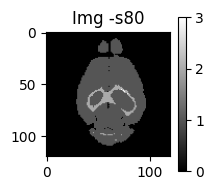

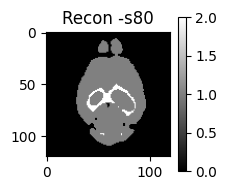

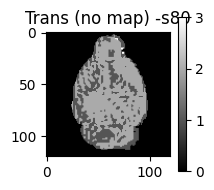

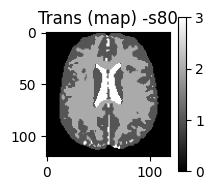

In [54]:
#img_arr = sitk.GetArrayFromImage(sitk.ReadImage(save_path + "trans_" + test_paths[0].split("/")[-1]))

slice_idx = 80

plot_img(img_arr.squeeze(), slice_idx, "Img -s" + str(slice_idx))
plot_img(recon_img, slice_idx, "Recon -s" + str(slice_idx))
plot_img(trans_img, slice_idx, "Trans (no map) -s" + str(slice_idx))
plot_img(trans_map_img, slice_idx, "Trans (map) -s" + str(slice_idx))

### Analyze distribution of latent encodings

Mean of means: 0.326
Std of means: 2.2048
Mean of stds: 0.4038
Std of stds: 0.6178
Mean of norms: 21.2425
Std of norms: 27.5829


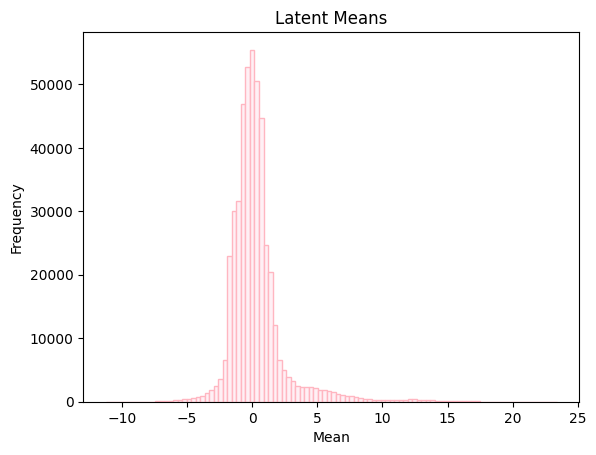

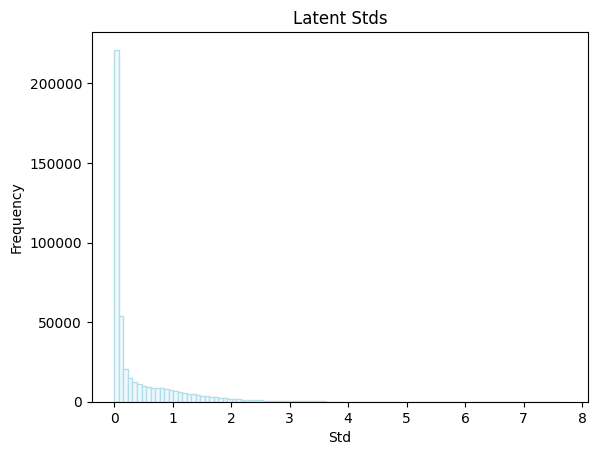

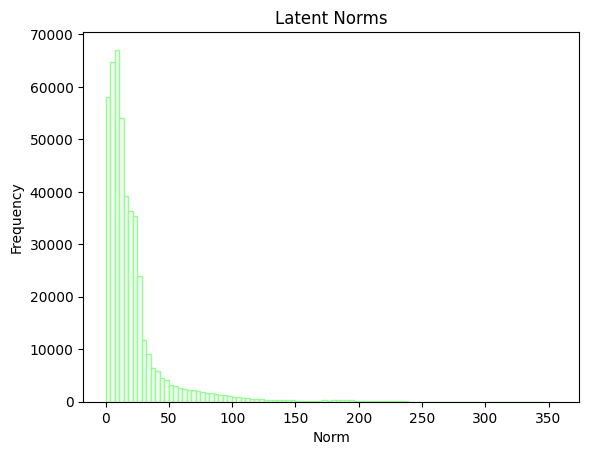

Mean of means: 0.4184
Std of means: 1.9784
Mean of stds: 0.4756
Std of stds: 0.3954
Mean of norms: 25.5449
Std of norms: 18.188


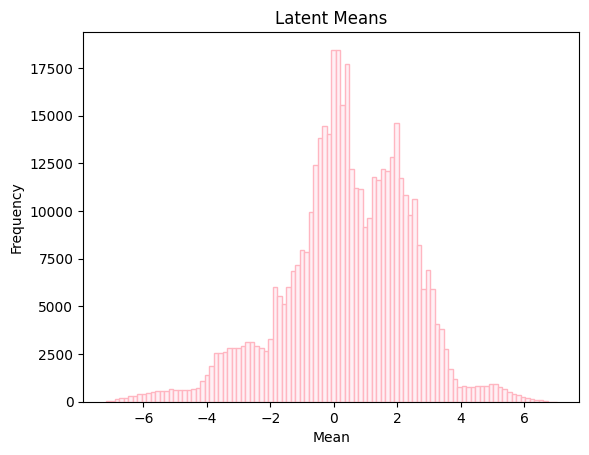

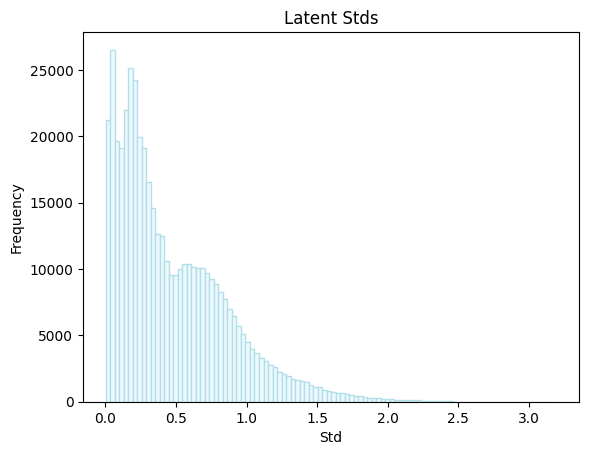

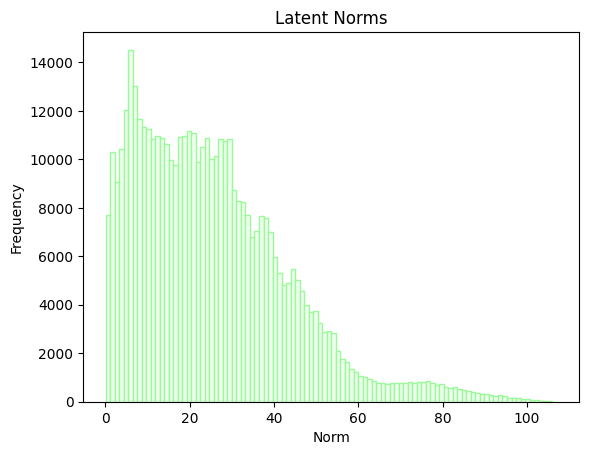

In [4]:
# Dataset
mouse_encodings_folder = "./save_models/mouse_train_5/train_latent_encodings/"
human_encodings_folder = "./save_models/human_train_5/train_latent_encodings/"

dataset = LatentVectorDataset(mouse_encodings_folder, human_encodings_folder)
batch_size = 220 # known num of train vectors
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

mouse_batch, human_batch = next(iter(dataloader))

def plot_latent_vect_dists(encodings):
    means = encodings.mean(dim=0)
    stds = encodings.std(dim=0)
    norms = encodings.norm(dim=0)

    print("Mean of means:", np.round(means.mean().numpy(), 4))
    print("Std of means:", np.round(means.std().numpy(), 4))

    print("Mean of stds:", np.round(stds.mean().numpy(), 4))
    print("Std of stds:", np.round(stds.std().numpy(), 4))

    print("Mean of norms:", np.round(norms.mean().numpy(), 4))
    print("Std of norms:", np.round(norms.std().numpy(), 4))

    plt.hist(means, bins=100, edgecolor="lightpink", color="lavenderblush")
    plt.xlabel("Mean")
    plt.ylabel("Frequency")
    plt.title("Latent Means")
    plt.show()

    plt.hist(stds, bins=100, edgecolor="powderblue", color="aliceblue")
    plt.xlabel("Std")
    plt.ylabel("Frequency")
    plt.title("Latent Stds")
    plt.show()

    plt.hist(norms, bins=100, edgecolor="palegreen", color="honeydew")
    plt.xlabel("Norm")
    plt.ylabel("Frequency")
    plt.title("Latent Norms")
    plt.show()

    return means, stds

mouse_means, mouse_stds = plot_latent_vect_dists(mouse_batch)
human_means, human_stds = plot_latent_vect_dists(human_batch)

